# 12. Model Checking, Calibration, and Posterior Predictive Logic

A Bayesian model can produce elegant posteriors and still be operationally misleading. Here we focus on what to do next: check whether the model reproduces the data patterns that matter, examine whether its probabilities are calibrated, and revise the model when those checks fail.


## Learning Objectives

After working through this lecture, you should be able to:

- explain the logic of posterior predictive checking,
- distinguish a model that fits one aggregate statistic from a model that captures the right structure,
- interpret calibration plots and simple calibration summaries,
- use model criticism to motivate a refined Bayesian model,
- understand how model checking can directly change a decision recommendation.


In [1]:
# Load the libraries and notebook settings used in the examples below.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import beta

# Keep tables readable in the rendered lecture notes.
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", None)

sns.set_theme(style="whitegrid", context="notebook")

# Stable colors make pooled-model checks, tier-aware checks, and observed statistics easy to distinguish.
COLORS = {
    "pooled": "#b45309",
    "tier": "#15803d",
    "obs": "#0f172a",
    "accent": "#2563eb",
    "warn": "#7c3aed",
}


def posterior_beta(prior_a, prior_b, successes, trials):
    """
    Update a beta prior after observing binomial event counts.

    Parameters:
        prior_a: Prior pseudo-count for Sev-1 incident releases.
        prior_b: Prior pseudo-count for non-Sev-1 releases.
        successes: Observed number of Sev-1 incident releases.
        trials: Total observed releases in the group being modeled.

    Returns:
        Posterior beta parameters `(a_post, b_post)` after adding observed incidents and non-incidents to the prior.

    Idea:
        The update is simple enough to inspect directly, which helps keep later posterior predictive checks transparent.
    """
    return prior_a + successes, prior_b + trials - successes


def beta_draws(alpha, beta_param, draws, rng):
    """
    Simulate event-probability draws from a beta posterior or prior.

    Parameters:
        alpha: Alpha parameter of the beta distribution.
        beta_param: Beta parameter of the beta distribution.
        draws: Number of probability draws to simulate.
        rng: NumPy random generator used for reproducible simulation.

    Returns:
        A NumPy array of plausible event probabilities sampled from the beta distribution.

    Idea:
        Probability draws are the bridge from posterior parameters to replicated data, calibration checks, and policy calculations.
    """
    return beta.rvs(alpha, beta_param, size=draws, random_state=rng)


def posterior_predictive_check(observed, replicated):
    """
    Summarize how an observed discrepancy compares with posterior predictive replicates.

    Parameters:
        observed: Observed value of the discrepancy statistic, such as total incidents or tier-rate gap.
        replicated: Simulated values of the same statistic from posterior predictive data sets.

    Returns:
        A dictionary with the observed statistic, predictive mean, predictive interval, upper-tail probability, and two-sided diagnostic probability.

    Idea:
        A model should be challenged on statistics that matter for the decision, not only on aggregate fit.
    """
    upper_tail = np.mean(replicated >= observed)
    return {
        "observed": observed,
        "replicated_mean": replicated.mean(),
        "predictive_90_lower": np.quantile(replicated, 0.05),
        "predictive_90_upper": np.quantile(replicated, 0.95),
        "ppp_upper_tail": upper_tail,
        "ppp_two_sided": 2 * min(upper_tail, 1 - upper_tail),
    }


## 1. Why Model Checking Matters in Bayesian Work

Bayesian updating tells us how to move from prior to posterior. It does **not** guarantee that the model family itself is adequate.

Posterior predictive checking asks whether data generated from the fitted model look plausibly like the data we actually observed. Formally,

$$
p(y^{\mathrm{rep}} \mid y) = \int p(y^{\mathrm{rep}} \mid \theta) p(\theta \mid y) \, d\theta,
$$

where $y^{\mathrm{rep}}$ is a replicated data set drawn from the posterior predictive distribution.

We then choose a discrepancy statistic $T(\cdot)$ and compare the observed value with its posterior predictive reference distribution:

$$
p_{\mathrm{ppc}} = \Pr\left(T(y^{\mathrm{rep}}) \ge T(y) \mid y\right).
$$

The goal is not to produce a classical hypothesis test. The goal is to ask a diagnostic question:

> If the model were the data-generating story, would it regularly produce data sets with the kind of structure we just saw?

A complementary question is **calibration**: when the model predicts an event probability of, say, 0.25, do such events occur about 25% of the time in comparable cases?


## 2. Case Study: Release-Risk Forecasting for Sev-1 Incidents

A platform reliability team monitors whether major software releases trigger a **Sev-1 incident**. Releases are categorized before launch into three operational risk tiers:

- **Low-risk:** small, routine, well-tested changes,
- **Medium-risk:** moderate changes with some integration complexity,
- **High-risk:** large or architecture-touching changes requiring close scrutiny.

The team starts with a simple Bayesian model that treats all releases as exchangeable and estimates one common severe-incident probability. That is computationally easy, but we will see that it misses the structure that actually matters.

### Variable Guide

| Variable | Meaning | Why it matters |
| --- | --- | --- |
| `risk_tier` | Pre-launch operational risk bucket | Candidate source of heterogeneity |
| `n_releases` | Number of releases in a tier | Controls posterior precision |
| `sev1_releases` | Releases that triggered a Sev-1 incident | Primary binary outcome |
| `theta` | Latent severe-incident probability | The core forecast quantity |
| `y_rep` | Posterior predictive replicate | Used for model checking |
| `ppp` | Posterior predictive probability summary | Diagnostic indicator, not a classical p-value |


In [2]:
# Build tier-level data and expand it to release-level records for calibration metrics.
tier_summary = pd.DataFrame(
    [
        {"risk_tier": "Low-risk", "n_releases": 70, "sev1_releases": 5},
        {"risk_tier": "Medium-risk", "n_releases": 65, "sev1_releases": 15},
        {"risk_tier": "High-risk", "n_releases": 45, "sev1_releases": 24},
    ]
)
tier_summary["observed_rate"] = tier_summary["sev1_releases"] / tier_summary["n_releases"]

# The release-level table lets us compute Brier scores against individual binary outcomes.
release_records = []
for _, row in tier_summary.iterrows():
    outcomes = [1] * int(row["sev1_releases"]) + [0] * int(row["n_releases"] - row["sev1_releases"])
    for idx, outcome in enumerate(outcomes, start=1):
        release_records.append(
            {
                "risk_tier": row["risk_tier"],
                "release_in_tier_id": idx,
                "sev1_incident": outcome,
            }
        )

release_level = pd.DataFrame(release_records)

display(tier_summary.round(3))


,risk_tier,n_releases,sev1_releases,observed_rate
0,Low-risk,70,5,0.071
1,Medium-risk,65,15,0.231
2,High-risk,45,24,0.533


The tier summary is a first model-checking clue. If release risk differs sharply across tiers, then a pooled forecast is likely to miss systematic structure. This table gives the later posterior predictive checks something concrete to test.

## 3. A Prior Predictive Sense Check for the Pooled Model

Before fitting the pooled model, we ask whether its prior is at least broadly compatible with plausible total incident counts.

We place

$$
\theta \sim \text{Beta}(8, 32),
$$

which centers the overall severe-incident rate around 20% with moderate prior strength. Under the pooled model, all 180 releases share this same latent probability.


In [3]:
# Simulate total incident counts before seeing data to test prior plausibility.
rng = np.random.default_rng(20260614)
draws = 160_000

pooled_prior_a, pooled_prior_b = 8, 32
total_releases = int(tier_summary["n_releases"].sum())
total_incidents = int(tier_summary["sev1_releases"].sum())

# Draw a prior incident probability, then draw a replicated total count for 180 releases.
theta_prior = beta_draws(pooled_prior_a, pooled_prior_b, draws, rng)
prior_predictive_total = rng.binomial(total_releases, theta_prior)

prior_predictive_summary = pd.DataFrame(
    [
        {
            "quantity": "Prior mean incident probability",
            "value": pooled_prior_a / (pooled_prior_a + pooled_prior_b),
        },
        {
            "quantity": "Observed total Sev-1 releases",
            "value": total_incidents,
        },
        {
            "quantity": "Prior predictive mean total incidents",
            "value": prior_predictive_total.mean(),
        },
        {
            "quantity": "Prior predictive 90% interval lower bound",
            "value": np.quantile(prior_predictive_total, 0.05),
        },
        {
            "quantity": "Prior predictive 90% interval upper bound",
            "value": np.quantile(prior_predictive_total, 0.95),
        },
    ]
)

display(prior_predictive_summary.round(3))


,quantity,value
0,Prior mean incident probability,0.200
1,Observed total Sev-1 releases,44.000
2,Prior predictive mean total incidents,36.001
3,Prior predictive 90% interval lower bound,17.000
4,Prior predictive 90% interval upper bound,58.000


The prior predictive check says the prior is not obviously incompatible with the total number of Sev-1 releases. The observed total of 44 sits well inside the prior predictive interval. That is useful, but deliberately incomplete. A prior can be reasonable for the aggregate total while still being too simple for the pattern across risk tiers.

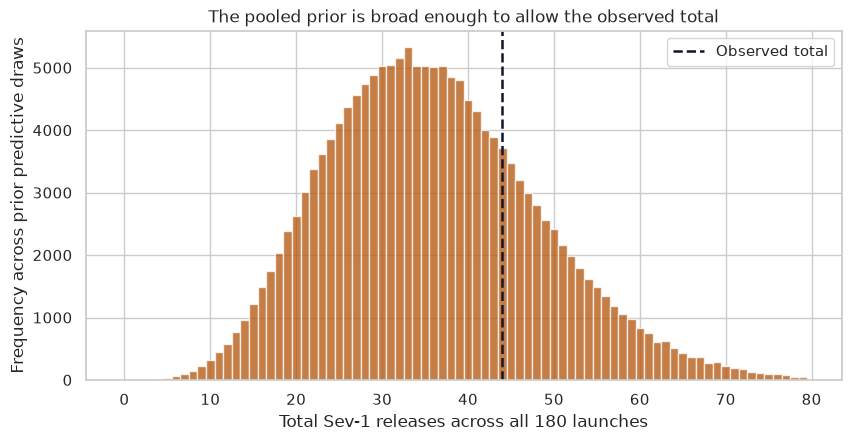

In [4]:
# Plot the prior predictive total count against the observed total incident count.
fig, ax = plt.subplots(figsize=(8.4, 4.3), constrained_layout=True)
ax.hist(prior_predictive_total, bins=np.arange(0, 81) - 0.5, color=COLORS["pooled"], alpha=0.75)
ax.axvline(total_incidents, color=COLORS["obs"], linestyle="--", linewidth=1.8, label="Observed total")
ax.set_title("The pooled prior is broad enough to allow the observed total")
ax.set_xlabel("Total Sev-1 releases across all 180 launches")
ax.set_ylabel("Frequency across prior predictive draws")
ax.legend(frameon=True)
plt.show()


The prior predictive check is reassuring but limited. It tells us the pooled model is not absurd at the level of the **overall** incident count. It does **not** tell us whether the pooled model captures how risk varies across release types.

That distinction is the heart of the exercise.

## 4. Fitting the Pooled Model and Designing Posterior Predictive Checks

Under the pooled model,

$$
y_i \mid \theta \sim \text{Bernoulli}(\theta), \qquad \theta \sim \text{Beta}(8, 32),
$$

so the posterior is

$$
\theta \mid y \sim \text{Beta}(8 + 44, 32 + 180 - 44) = \text{Beta}(52, 168).
$$

We deliberately choose discrepancy statistics that probe different aspects of fit:

- **Total incidents**: a basic aggregate check,
- **High-risk-tier incidents**: does the model capture the severe tail of operational risk?
- **Tier rate gap**: how separated are the most and least risky tiers?
- **Standard deviation of tier rates**: how much heterogeneity is present across tiers?


In [5]:
# Fit the pooled beta-binomial model and replicate tier-level data under that model.
pooled_post_a, pooled_post_b = posterior_beta(
    pooled_prior_a, pooled_prior_b, total_incidents, total_releases
)
pooled_theta = beta_draws(pooled_post_a, pooled_post_b, draws, rng)

# Every tier receives the same posterior incident probability under the pooled exchangeability assumption.
replicated_counts_pooled = np.column_stack(
    [rng.binomial(int(n_i), pooled_theta) for n_i in tier_summary["n_releases"]]
)
replicated_rates_pooled = replicated_counts_pooled / tier_summary["n_releases"].to_numpy()

observed_rates = tier_summary["observed_rate"].to_numpy()

# These checks target aggregate fit, high-risk tail behavior, and cross-tier heterogeneity.
pooled_ppc = pd.DataFrame(
    [
        {
            "statistic": "Total incidents",
            **posterior_predictive_check(total_incidents, replicated_counts_pooled.sum(axis=1)),
        },
        {
            "statistic": "High-risk-tier incidents",
            **posterior_predictive_check(
                int(tier_summary.loc[tier_summary["risk_tier"] == "High-risk", "sev1_releases"].iloc[0]),
                replicated_counts_pooled[:, 2],
            ),
        },
        {
            "statistic": "Tier rate gap",
            **posterior_predictive_check(
                observed_rates.max() - observed_rates.min(),
                replicated_rates_pooled.max(axis=1) - replicated_rates_pooled.min(axis=1),
            ),
        },
        {
            "statistic": "SD of tier rates",
            **posterior_predictive_check(
                observed_rates.std(ddof=0),
                replicated_rates_pooled.std(axis=1, ddof=0),
            ),
        },
    ]
)

pooled_ppc_display = pooled_ppc[
    [
        "statistic",
        "observed",
        "replicated_mean",
        "predictive_90_lower",
        "predictive_90_upper",
        "ppp_upper_tail",
        "ppp_two_sided",
    ]
]

display(pooled_ppc_display.round(3))


,statistic,observed,replicated_mean,predictive_90_lower,predictive_90_upper,ppp_upper_tail,ppp_two_sided
0,Total incidents,44.000,42.571,30.000,56.000,0.44,0.879
1,High-risk-tier incidents,24.000,10.645,6.000,16.000,0.00,0.000
2,Tier rate gap,0.462,0.094,0.024,0.185,0.00,0.000
3,SD of tier rates,0.192,0.040,0.010,0.079,0.00,0.000


The posterior predictive table shows why the choice of discrepancy statistic matters. The pooled model is acceptable on total incidents, with the observed count close to the replicated mean. But it fails badly on the high-risk tier and on the spread between tiers. The model can reproduce the total only by putting roughly the same risk everywhere, which is exactly the wrong structure for deciding where reliability review should be focused.

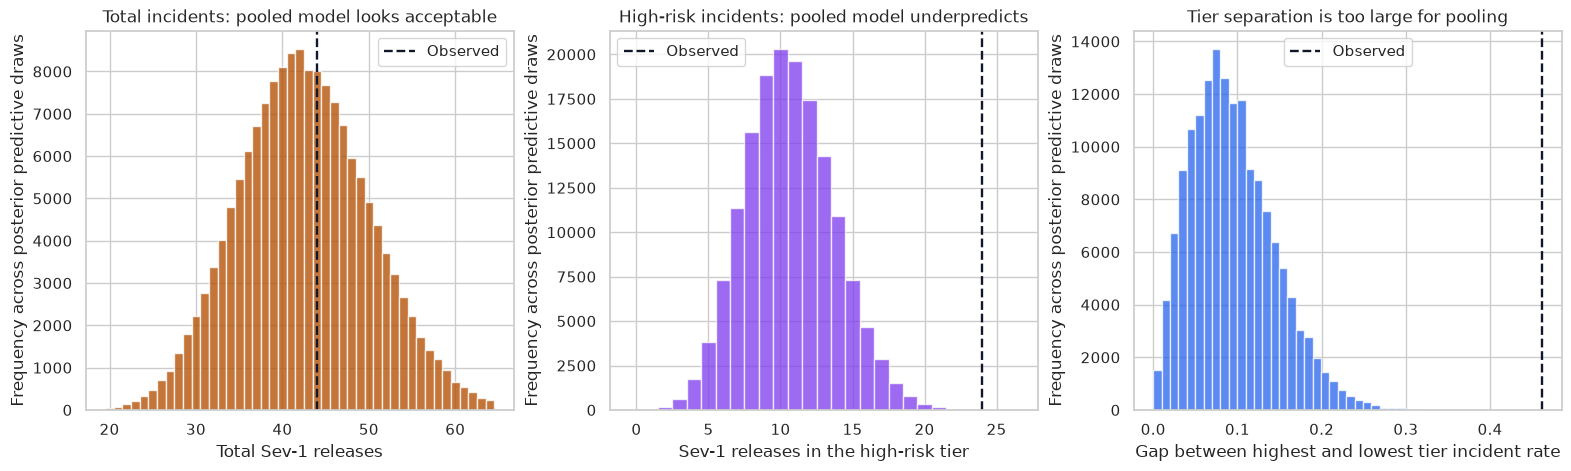

In [6]:
# Visualize aggregate fit and structural misfit side by side.
pooled_rate = pooled_post_a / (pooled_post_a + pooled_post_b)

fig, axes = plt.subplots(1, 3, figsize=(15.6, 4.6), constrained_layout=True)

total_rep = replicated_counts_pooled.sum(axis=1)
axes[0].hist(total_rep, bins=np.arange(20, 66) - 0.5, color=COLORS["pooled"], alpha=0.8)
axes[0].axvline(total_incidents, color=COLORS["obs"], linestyle="--", linewidth=1.7, label="Observed")
axes[0].set_title("Total incidents: pooled model looks acceptable")
axes[0].set_xlabel("Total Sev-1 releases")
axes[0].set_ylabel("Frequency across posterior predictive draws")
axes[0].legend(frameon=True)

high_rep = replicated_counts_pooled[:, 2]
axes[1].hist(high_rep, bins=np.arange(0, 28) - 0.5, color=COLORS["warn"], alpha=0.75)
axes[1].axvline(24, color=COLORS["obs"], linestyle="--", linewidth=1.7, label="Observed")
axes[1].set_title("High-risk incidents: pooled model underpredicts")
axes[1].set_xlabel("Sev-1 releases in the high-risk tier")
axes[1].set_ylabel("Frequency across posterior predictive draws")
axes[1].legend(frameon=True)

gap_rep = replicated_rates_pooled.max(axis=1) - replicated_rates_pooled.min(axis=1)
observed_gap = observed_rates.max() - observed_rates.min()
axes[2].hist(gap_rep, bins=40, color=COLORS["accent"], alpha=0.75)
axes[2].axvline(observed_gap, color=COLORS["obs"], linestyle="--", linewidth=1.7, label="Observed")
axes[2].set_title("Tier separation is too large for pooling")
axes[2].set_xlabel("Gap between highest and lowest tier incident rate")
axes[2].set_ylabel("Frequency across posterior predictive draws")
axes[2].legend(frameon=True)

plt.show()


This is the classic “aggregate fit versus structural fit” trap.

- The pooled model can reproduce the **overall** count reasonably well.
- But it catastrophically misses where the incidents are concentrated.
- The posterior predictive probabilities for the high-risk count and tier-gap statistics are effectively at the boundary.

That is a strong diagnostic signal that the exchangeability assumption is wrong for this decision problem.

A caution is important here: posterior predictive probabilities are useful diagnostics, but they are not classical uniform p-values. They are evidence of model-data tension, not a one-number decision oracle.

## 5. Calibration of the Pooled Forecast

Posterior predictive checks ask whether replicated data look plausible under the model. Calibration asks a complementary question:

> When the model predicts a certain probability, do comparable cases actually realize the event at about that frequency?

Under the pooled model, every release gets the same posterior mean probability. That already suggests trouble: the model cannot be calibrated across tiers if it refuses to differentiate them.


In [7]:
# Compute calibration summaries for the pooled forecast.
reliability_table = tier_summary[["risk_tier", "n_releases", "sev1_releases", "observed_rate"]].copy()
reliability_table["pooled_predicted_rate"] = pooled_rate

pooled_ece = np.average(
    np.abs(reliability_table["pooled_predicted_rate"] - reliability_table["observed_rate"]),
    weights=reliability_table["n_releases"],
)
pooled_brier = np.mean((release_level["sev1_incident"] - pooled_rate) ** 2)

pooled_calibration_metrics = pd.DataFrame(
    [
        {"metric": "Expected calibration error (tier-weighted)", "value": pooled_ece},
        {"metric": "Brier score", "value": pooled_brier},
    ]
)

display(reliability_table.round(3))
display(pooled_calibration_metrics.round(3))


,risk_tier,n_releases,sev1_releases,observed_rate,pooled_predicted_rate
0,Low-risk,70,5,0.071,0.236
1,Medium-risk,65,15,0.231,0.236
2,High-risk,45,24,0.533,0.236


,metric,value
0,Expected calibration error (tier-weighted),0.140
1,Brier score,0.185


The calibration table makes the pooled-model failure concrete. Every tier receives the same predicted risk, about 0.236. That slightly matches the medium-risk tier, badly overpredicts low-risk releases, and badly underpredicts high-risk releases. The expected calibration error is therefore not a minor numerical detail. It measures the operational danger of using one probability for groups with very different realized risks.

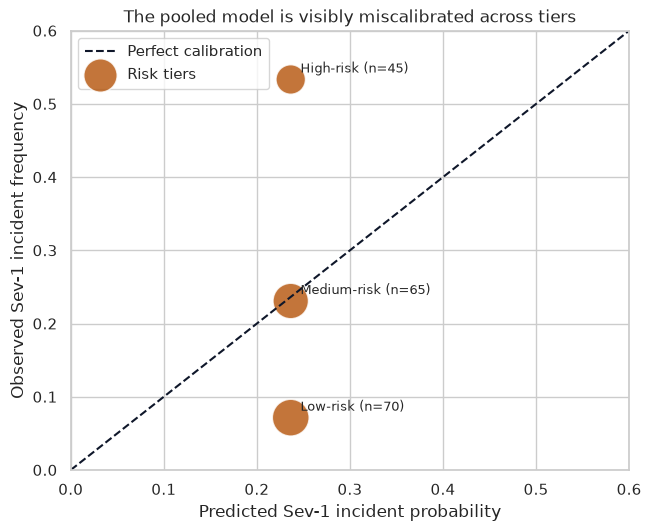

In [8]:
# Plot predicted probabilities against observed frequencies for each risk tier.
fig, ax = plt.subplots(figsize=(6.4, 5.2), constrained_layout=True)
ax.plot([0, 0.6], [0, 0.6], color=COLORS["obs"], linestyle="--", linewidth=1.5, label="Perfect calibration")

# Bubble area encodes how many releases support each calibration point.
bubble_sizes = reliability_table["n_releases"] * 10
ax.scatter(
    reliability_table["pooled_predicted_rate"],
    reliability_table["observed_rate"],
    s=bubble_sizes,
    color=COLORS["pooled"],
    alpha=0.8,
    edgecolor="white",
    linewidth=1.0,
    label="Risk tiers",
)

for _, row in reliability_table.iterrows():
    ax.annotate(
        f"{row['risk_tier']} (n={int(row['n_releases'])})",
        (row["pooled_predicted_rate"], row["observed_rate"]),
        textcoords="offset points",
        xytext=(7, 5),
        fontsize=9,
    )

ax.set_xlim(0.0, 0.6)
ax.set_ylim(0.0, 0.6)
ax.set_title("The pooled model is visibly miscalibrated across tiers")
ax.set_xlabel("Predicted Sev-1 incident probability")
ax.set_ylabel("Observed Sev-1 incident frequency")
ax.legend(frameon=True, loc="upper left")
plt.show()


The pooled model's problem is now obvious from a second angle:

- it overpredicts low-risk releases,
- slightly overpredicts medium-risk releases,
- and badly underpredicts high-risk releases.

Calibration matters because operations teams act on forecasted probabilities, not on the philosophical elegance of an exchangeable prior.

## 6. Refining the Model: Tier-Aware Bayesian Risk Forecasting

The posterior predictive failure suggests a simple repair: allow each risk tier to have its own severe-incident probability.

We specify independent Beta-Binomial components:

$$
\theta_j \sim \text{Beta}(a_j, b_j), \qquad
y_j \mid \theta_j \sim \text{Binomial}(n_j, \theta_j),
$$

for tiers $j \in \{\text{low}, \text{medium}, \text{high}\}$.

These priors encode weak historical beliefs that higher-risk tiers should have larger incident probabilities:

- low-risk prior mean: 0.10,
- medium-risk prior mean: 0.20,
- high-risk prior mean: 0.40.


In [9]:
# Specify weakly informative tier-specific priors and update each tier separately.
tier_priors = pd.DataFrame(
    [
        {"risk_tier": "Low-risk", "prior_a": 4, "prior_b": 36},
        {"risk_tier": "Medium-risk", "prior_a": 8, "prior_b": 32},
        {"risk_tier": "High-risk", "prior_a": 12, "prior_b": 18},
    ]
)
tier_priors["prior_mean"] = tier_priors["prior_a"] / (tier_priors["prior_a"] + tier_priors["prior_b"])

tier_model = tier_summary.merge(tier_priors, on="risk_tier", how="left")
tier_model["posterior_a"] = tier_model["prior_a"] + tier_model["sev1_releases"]
tier_model["posterior_b"] = tier_model["prior_b"] + tier_model["n_releases"] - tier_model["sev1_releases"]
tier_model["posterior_mean"] = tier_model["posterior_a"] / (tier_model["posterior_a"] + tier_model["posterior_b"])

display(
    tier_model[
        [
            "risk_tier",
            "prior_mean",
            "observed_rate",
            "posterior_mean",
            "n_releases",
            "sev1_releases",
        ]
    ].round(3)
)


,risk_tier,prior_mean,observed_rate,posterior_mean,n_releases,sev1_releases
0,Low-risk,0.1,0.071,0.082,70,5
1,Medium-risk,0.2,0.231,0.219,65,15
2,High-risk,0.4,0.533,0.480,45,24


The tier-aware model keeps the same beta-binomial logic but relaxes the exchangeability assumption. Each tier now has its own prior and posterior incident probability. The posterior means follow the operational ordering we expected: low-risk releases are low, medium-risk releases are intermediate, and high-risk releases are much higher. This is a better match to the forecasting task because the model can express the structure that operations already uses before launch.

In [10]:
# Replicate tier-level data from the tier-aware posterior and re-run the same checks.
tier_theta = np.column_stack(
    [
        beta_draws(row["posterior_a"], row["posterior_b"], draws, rng)
        for _, row in tier_model.iterrows()
    ]
)
replicated_counts_tier = np.column_stack(
    [rng.binomial(int(row["n_releases"]), tier_theta[:, idx]) for idx, (_, row) in enumerate(tier_model.iterrows())]
)
replicated_rates_tier = replicated_counts_tier / tier_model["n_releases"].to_numpy()

# Reusing the exact same discrepancy statistics makes the pooled and tier-aware models comparable.
tier_ppc = pd.DataFrame(
    [
        {
            "statistic": "Total incidents",
            **posterior_predictive_check(total_incidents, replicated_counts_tier.sum(axis=1)),
        },
        {
            "statistic": "High-risk-tier incidents",
            **posterior_predictive_check(24, replicated_counts_tier[:, 2]),
        },
        {
            "statistic": "Tier rate gap",
            **posterior_predictive_check(
                observed_rates.max() - observed_rates.min(),
                replicated_rates_tier.max(axis=1) - replicated_rates_tier.min(axis=1),
            ),
        },
        {
            "statistic": "SD of tier rates",
            **posterior_predictive_check(
                observed_rates.std(ddof=0),
                replicated_rates_tier.std(axis=1, ddof=0),
            ),
        },
    ]
)

model_check_comparison = pooled_ppc_display[
    ["statistic", "ppp_two_sided"]
].rename(columns={"ppp_two_sided": "pooled_model_ppp"})
model_check_comparison["tier_model_ppp"] = tier_ppc["ppp_two_sided"].to_numpy()

display(model_check_comparison.round(3))


,statistic,pooled_model_ppp,tier_model_ppp
0,Total incidents,0.879,0.752
1,High-risk-tier incidents,0.000,0.654
2,Tier rate gap,0.000,0.552
3,SD of tier rates,0.000,0.604


The model-check comparison shows a clean before-and-after story. The pooled model has acceptable predictive behavior for the total count but collapses on the high-risk count and heterogeneity statistics. The tier-aware model produces non-boundary posterior predictive probabilities for the same checks. The tier-aware model removes the most obvious structural failure. Full adequacy would still require additional checks.

,metric,pooled_model,tier_model
0,Expected calibration error (tier-weighted),0.140,0.022
1,Brier score,0.185,0.153


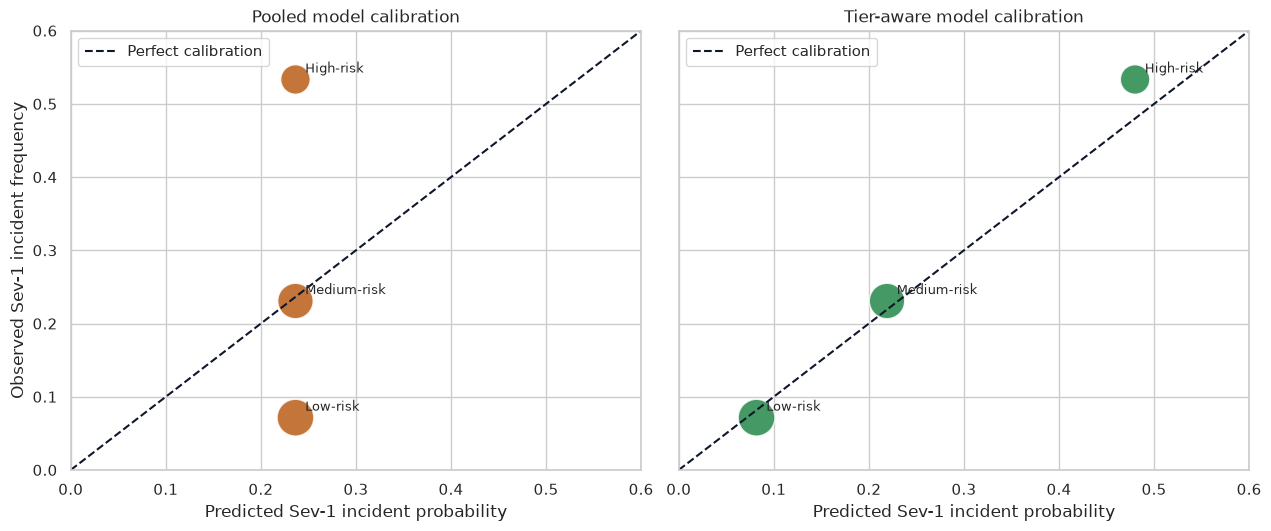

In [11]:
# Compare pooled and tier-aware calibration on the same reliability diagram.
reliability_table["tier_model_predicted_rate"] = tier_model["posterior_mean"].to_numpy()

tier_ece = np.average(
    np.abs(reliability_table["tier_model_predicted_rate"] - reliability_table["observed_rate"]),
    weights=reliability_table["n_releases"],
)

# Attach tier-aware predictions to release-level outcomes before computing a Brier score.
release_level = release_level.merge(
    reliability_table[["risk_tier", "tier_model_predicted_rate"]],
    on="risk_tier",
    how="left",
)
tier_brier = np.mean((release_level["sev1_incident"] - release_level["tier_model_predicted_rate"]) ** 2)

calibration_comparison = pd.DataFrame(
    [
        {"metric": "Expected calibration error (tier-weighted)", "pooled_model": pooled_ece, "tier_model": tier_ece},
        {"metric": "Brier score", "pooled_model": pooled_brier, "tier_model": tier_brier},
    ]
)

display(calibration_comparison.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.2), sharex=True, sharey=True, constrained_layout=True)

for ax, pred_col, title, color in [
    (axes[0], "pooled_predicted_rate", "Pooled model calibration", COLORS["pooled"]),
    (axes[1], "tier_model_predicted_rate", "Tier-aware model calibration", COLORS["tier"]),
]:
    ax.plot([0, 0.6], [0, 0.6], color=COLORS["obs"], linestyle="--", linewidth=1.5, label="Perfect calibration")
    ax.scatter(
        reliability_table[pred_col],
        reliability_table["observed_rate"],
        s=reliability_table["n_releases"] * 10,
        color=color,
        alpha=0.8,
        edgecolor="white",
        linewidth=1.0,
    )
    for _, row in reliability_table.iterrows():
        ax.annotate(
            row["risk_tier"],
            (row[pred_col], row["observed_rate"]),
            textcoords="offset points",
            xytext=(7, 5),
            fontsize=9,
        )
    ax.set_title(title)
    ax.set_xlabel("Predicted Sev-1 incident probability")
    ax.legend(frameon=True, loc="upper left")

axes[0].set_ylabel("Observed Sev-1 incident frequency")
axes[0].set_xlim(0.0, 0.6)
axes[0].set_ylim(0.0, 0.6)

plt.show()


The refined model does two important things better:

1. its posterior predictive checks no longer show strong model-data tension on the key risk-structure statistics,
2. its predicted probabilities are much closer to observed frequencies across release tiers.

This does **not** prove the tier-aware model is “true.” It simply means it is substantially more adequate for the decision problem at hand.

## 7. Decision Consequence: Should High-Risk Releases Receive Mandatory Reliability Review?

Suppose the organization can afford mandatory pre-release reliability review only for releases whose predicted Sev-1 probability exceeds **0.30**.

Under the pooled model, every release gets the same posterior mean probability, so no tier would cross the threshold. Under the tier-aware model, the high-risk tier clearly does.

To make the stakes concrete, suppose:

- a mandatory review reduces the severe-incident probability of flagged releases by **35%**,
- each avoided Sev-1 incident is worth **\$100,000** in downstream disruption avoided,
- each mandatory review costs **\$1,500** in engineering time.


,model,flagged_tiers,releases_flagged,expected_incidents_flagged,expected_incidents_avoided,expected_review_cost,expected_net_value
0,Pooled model,None,0,0.0,0.00,0.0,0.0
1,Tier-aware model,High-risk,45,21.6,7.56,67500.0,688500.0


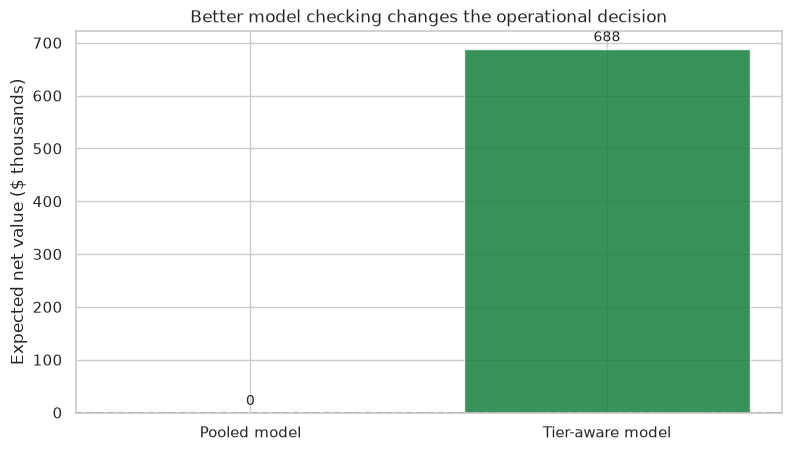

In [12]:
# Translate the model forecasts into a threshold-based reliability-review policy.
review_threshold = 0.30
review_effect = 0.35
cost_per_avoided_incident = 100_000
review_cost_per_release = 1_500

# Only tiers above the decision threshold receive mandatory review.
flagged_tier_mask = reliability_table["tier_model_predicted_rate"] > review_threshold
expected_incidents_flagged = float(
    (reliability_table.loc[flagged_tier_mask, "n_releases"] * reliability_table.loc[flagged_tier_mask, "tier_model_predicted_rate"]).sum()
)
expected_incidents_avoided = expected_incidents_flagged * review_effect
expected_review_cost = float(reliability_table.loc[flagged_tier_mask, "n_releases"].sum() * review_cost_per_release)
expected_net_value = expected_incidents_avoided * cost_per_avoided_incident - expected_review_cost

# The pooled model flags no tier because its single predicted risk is below the threshold.
decision_table = pd.DataFrame(
    [
        {
            "model": "Pooled model",
            "flagged_tiers": "None",
            "releases_flagged": 0,
            "expected_incidents_flagged": 0.0,
            "expected_incidents_avoided": 0.0,
            "expected_review_cost": 0.0,
            "expected_net_value": 0.0,
        },
        {
            "model": "Tier-aware model",
            "flagged_tiers": ", ".join(reliability_table.loc[flagged_tier_mask, "risk_tier"]),
            "releases_flagged": int(reliability_table.loc[flagged_tier_mask, "n_releases"].sum()),
            "expected_incidents_flagged": expected_incidents_flagged,
            "expected_incidents_avoided": expected_incidents_avoided,
            "expected_review_cost": expected_review_cost,
            "expected_net_value": expected_net_value,
        },
    ]
)

display(decision_table.round(2))

# Plot expected net value on a thousand-dollar scale for readability.
fig, ax = plt.subplots(figsize=(7.8, 4.4), constrained_layout=True)
bars = ax.bar(
    decision_table["model"],
    decision_table["expected_net_value"] / 1_000,
    color=[COLORS["pooled"], COLORS["tier"]],
    alpha=0.85,
)
ax.axhline(0, color=COLORS["obs"], linestyle="--", linewidth=1.4)
ax.set_title("Better model checking changes the operational decision")
ax.set_ylabel("Expected net value ($ thousands)")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + (8 if height >= 0 else -12),
        f"{height:.0f}",
        ha="center",
        va="bottom" if height >= 0 else "top",
        fontsize=10,
    )

plt.show()


The key point is not the exact dollar number. The key point is that **model criticism changes action**.

- The pooled model would allocate no extra reliability review to the high-risk segment.
- The tier-aware model identifies a concentrated risk pocket and supports targeted intervention.

In decision science, an unchecked model can fail by allocating attention to the wrong places, even when the overall mean looks right.

<!-- real-data-companion-course01 -->
## Real-Data Companion: Calibration Check with the Spector Binary Outcome

The Spector dataset is small, but it is useful for demonstrating model checking because the outcome is binary and the fitted probabilities can be inspected directly. The target is whether a student's grade improved, using predictors such as GPA, test score, and program participation.

The unit is a student record. The companion fits a logistic regression model, obtains predicted probabilities, and checks whether those probabilities behave like probabilities when grouped or summarized. That is the calibration question: among cases assigned similar predicted risk, do observed outcomes occur at roughly the predicted rate?

This companion is not meant to be a high-stakes education policy model. It is a compact real-data example showing that model checking is not optional. A model can produce coefficients and p-values while still giving probabilities that need calibration review before they are used for decisions.

For clarity, the unit is a student record. The outcome is grade improvement, and the experiment checks whether logistic-model probabilities are calibrated enough to be interpreted as probabilities. The dataset is small by design, which makes model checking easy to inspect.

Data source: [Spector and Mazzeo data in statsmodels](https://www.statsmodels.org/stable/datasets/generated/spector.html).

,prob_bin,n,mean_predicted,observed_rate
0,"(0.0235, 0.0531]",8,0.032,0.000
1,"(0.0531, 0.217]",8,0.121,0.250
2,"(0.217, 0.601]",8,0.425,0.250
3,"(0.601, 0.945]",8,0.796,0.875


Brier score: 0.130


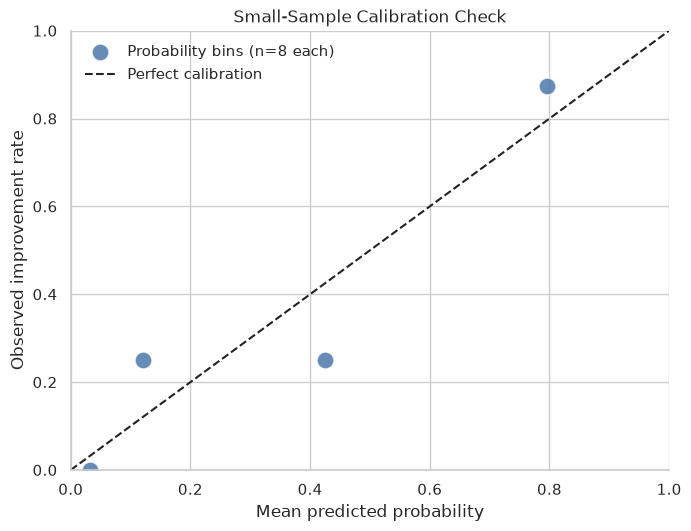

In [13]:
# real-data-companion-course01
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import brier_score_loss


def _find_project_root(start=Path.cwd()):
    """
    Find the nearest project root that exposes shared notebook helpers.

    Parameters:
        start: Directory from which the upward search begins, usually the current notebook working directory.

    Returns:
        The closest parent path containing `notebooks/_shared`; returns `start` when the helper directory is unavailable.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display
from notebooks._shared.real_data import load_statsmodels_spector, optional_data_note

RUN_REAL_DATA_COMPANION = True

if RUN_REAL_DATA_COMPANION:
    spector = load_statsmodels_spector().copy()

    # Fit a compact logistic model, then bin predictions to check probability calibration.
    X = sm.add_constant(spector[["GPA", "TUCE", "PSI"]])
    y = spector["GRADE"]
    logit = sm.Logit(y, X).fit(disp=False)
    spector["predicted_prob"] = logit.predict(X)
    spector["prob_bin"] = pd.qcut(spector["predicted_prob"], q=4, duplicates="drop")

    calibration = (
        spector.groupby("prob_bin", observed=False)
        .agg(n=("GRADE", "size"), mean_predicted=("predicted_prob", "mean"), observed_rate=("GRADE", "mean"))
        .reset_index()
    )
    smart_display(calibration.round(3))
    print(f"Brier score: {brier_score_loss(y, spector['predicted_prob']):.3f}")

    fig, ax = plt.subplots(figsize=(6.8, 5.2), constrained_layout=True)
    ax.scatter(
        calibration["mean_predicted"],
        calibration["observed_rate"],
        s=150,
        color="#4C78A8",
        alpha=0.85,
        edgecolor="white",
        linewidth=1.0,
        label="Probability bins (n=8 each)",
    )
    ax.plot([0, 1], [0, 1], color="#222222", linestyle="--", linewidth=1.5, label="Perfect calibration")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title("Small-Sample Calibration Check")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed improvement rate")
    ax.legend(frameon=False)
    sns.despine(fig=fig)
    plt.show()
else:
    optional_data_note(
        "Spector and Mazzeo Program Effectiveness Data",
        "https://www.statsmodels.org/stable/datasets/generated/spector.html",
        "RUN_REAL_DATA_COMPANION",
    )


<!-- real-data-companion-course01 -->
The small sample is part of the lesson. A calibration plot can look unstable when there are only a few cases per bin. That does not make the check useless. It tells us that model criticism should report both the diagnostic pattern and the amount of data supporting it.

## What to Remember

- Posterior updating is only part of Bayesian workflow; model checking is essential.
- A model can fit aggregate counts and still fail badly on structure that matters operationally.
- Posterior predictive checks are most useful when the discrepancy statistics target real decision concerns.
- Calibration is about whether predicted probabilities line up with realized frequencies.
- Better model criticism leads to better resource allocation and better diagnostics.


## References

- Dawid, A. P. (1982). *The well-calibrated Bayesian.* *Journal of the American Statistical Association, 77*(379), 605-610. [https://doi.org/10.1080/01621459.1982.10477856](https://doi.org/10.1080/01621459.1982.10477856)
- Gneiting, T., Balabdaoui, F., & Raftery, A. E. (2007). *Probabilistic forecasts, calibration and sharpness.* *Journal of the Royal Statistical Society: Series B (Statistical Methodology), 69*(2), 243-268. [https://doi.org/10.1111/j.1467-9868.2007.00587.x](https://doi.org/10.1111/j.1467-9868.2007.00587.x)
- Moran, G. E., Cunningham, J. P., & Blei, D. M. (2023). *The posterior predictive null.* *Bayesian Analysis, 18*(4). [https://doi.org/10.1214/22-BA1313](https://doi.org/10.1214/22-BA1313)
- van Kollenburg, G., Mulder, J., & Vermunt, J. K. (2017). *Posterior calibration of posterior predictive p values.* *Psychological Methods, 22*(2), 382-396. [https://doi.org/10.1037/met0000142](https://doi.org/10.1037/met0000142)
